# Análisis de Series Temporales — TP1
### Movilidad Urbana en Buenos Aires: Subte, Peajes y Precipitaciones

**Universidad Austral · Maestría de Ciencia de Datos**  

**Integrantes:**
- Alvaro, Giuliana
- Chalup, Sarah
- Fontán, Mariana
- Franco, Agustina

## Setup librerías e Imports

In [2]:
# ── Manipulación de datos ──────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualización ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Series temporales ─────────────────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera

# ── Métricas ──────────────────────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# ── Descarga de datos ─────────────────────────────────────────────────────
import requests
import zipfile
import io
import os
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# ── Configuración de plots ─────────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize': (14, 4),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

# ── Directorio de datos ────────────────────────────────────────────────────
DATA_DIR = Path('datos_tp1')
DATA_DIR.mkdir(exist_ok=True)

print('Setup completo ✓')

Setup completo ✓


## 1. Creación de los Datasets

### ⚡ Carga Rápida

Si ya descargaste los datos al menos una vez, **ejecutá solo esta celda** y se ignora la carga de los datasets anuales

In [3]:
from pathlib import Path
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('datos_tp1')

NECESARIOS = ['subte_mensual.csv', 'lluvia_mensual.csv', 'peajes_mensual.csv']
faltantes  = [f for f in NECESARIOS if not (DATA_DIR / f).exists()]

if faltantes:
    print(f'⚠️  Faltan archivos: {faltantes}')
    print('   Corré primero la Sección 1 (Descarga y Procesamiento de Datos).')
else:
    subte_mensual  = pd.read_csv(DATA_DIR / 'subte_mensual.csv',
                                  index_col=0, parse_dates=True).squeeze()
    lluvia_mensual = pd.read_csv(DATA_DIR / 'lluvia_mensual.csv',
                                  index_col=0, parse_dates=True).squeeze()
    peajes_mensual = pd.read_csv(DATA_DIR / 'peajes_mensual.csv',
                                  index_col=0, parse_dates=True).squeeze()

    START, END  = '2013-06-01', '2025-12-01'
    TRAIN_END   = '2023-12-01'
    TEST_START  = '2024-01-01'

    df = pd.DataFrame({
        'pasajeros_subte':  subte_mensual,
        'vehiculos_peajes': peajes_mensual,
        'lluvia_mm':        lluvia_mensual,
    }).loc[START:END]
    df['dummy_covid'] = 0
    df.loc['2020-03-01':'2021-12-01', 'dummy_covid'] = 1

    train = df.loc[:TRAIN_END]
    test  = df.loc[TEST_START:]

    print('✅ Datos cargados correctamente. Podés saltar a la Sección 2.')
    print(f'   Período  : {df.index[0].date()} -> {df.index[-1].date()} ({len(df)} obs)')
    print(f'   Train    : {train.index[0].date()} -> {train.index[-1].date()} ({len(train)} obs)')
    print(f'   Test     : {test.index[0].date()} -> {test.index[-1].date()} ({len(test)} obs)')
    print(f'   COVID    : {df["dummy_covid"].sum()} meses marcados')
    display(df.tail())

✅ Datos cargados correctamente. Podés saltar a la Sección 2.
   Período  : 2013-06-01 -> 2025-12-01 (151 obs)
   Train    : 2013-06-01 -> 2023-12-01 (127 obs)
   Test     : 2024-01-01 -> 2025-12-01 (24 obs)
   COVID    : 22 meses marcados


,pasajeros_subte,vehiculos_peajes,lluvia_mm,dummy_covid
fecha,,,,
2025-08-01,13563219.0,12717526.0,124.0,0
2025-09-01,19713080.0,12469675.0,94.7,0
2025-10-01,19432742.0,12915420.0,94.8,0
2025-11-01,17182572.0,12578370.0,89.5,0
2025-12-01,16418363.0,12759961.0,47.5,0


### 1.1 Data precipitaciones - MeteoAPI

In [4]:
def descargar_precipitaciones(start='2013-06-01', end='2025-12-31'):
    """Descarga datos diarios de precipitación de Open-Meteo y agrega a mensual."""
    url = (
        f"https://archive-api.open-meteo.com/v1/archive"
        f"?latitude=-34.60&longitude=-58.37"
        f"&start_date={start}&end_date={end}"
        f"&daily=precipitation_sum"
        f"&timezone=America%2FArgentina%2FBuenos_Aires"
        f"&format=csv"
    )
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    
    # El CSV de Open-Meteo tiene 3 líneas de encabezado
    df = pd.read_csv(io.StringIO(resp.text), skiprows=3, parse_dates=['time'])
    df = df.rename(columns={'time': 'fecha', 'precipitation_sum (mm)': 'lluvia_mm'})
    df = df.set_index('fecha')
    
    # Agregar a mensual
    lluvia_mensual = df['lluvia_mm'].resample('MS').sum()
    lluvia_mensual.name = 'lluvia_mm'
    return lluvia_mensual

lluvia = descargar_precipitaciones()
lluvia.to_csv(DATA_DIR / 'lluvia_mensual.csv')
print(f'Precipitaciones: {len(lluvia)} observaciones mensuales')
print(f'Período: {lluvia.index[0].date()} → {lluvia.index[-1].date()}')
lluvia.head()

Precipitaciones: 151 observaciones mensuales
Período: 2013-06-01 → 2025-12-01


fecha
2013-06-01      8.6
2013-07-01     78.2
2013-08-01      6.8
2013-09-01    102.4
2013-10-01     27.5
Freq: MS, Name: lluvia_mm, dtype: float64

### 1.2 Subte - Molinetes GCBA
> Los archivos CSV/ZIP se descargan desde el portal de datos abiertos del GCBA.  
> Por el tamaño de los archivos, se procesan año por año y se consolidan en un único CSV mensual.

In [12]:
# ── URLs verificadas (abril 2026) ─────────────────────────────────────────
SUBTE_URLS = {
    2013: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2013-junio-diciembre.zip',
    2014: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2014.zip',
    2015: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2015.zip',
    2016: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2016.zip',
    2017: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2017.zip',
    2018: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2018.zip',
    2019: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2019.zip',
    2020: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2020.zip',
    2021: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2021.zip',
    2022: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2022.zip',
    2023: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2023.zip',
    2024: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2024.zip',
    2025: 'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/subte-viajes-molinetes/molinetes-2025.zip',
}

def limpiar_raw(raw_bytes):
    """
    Quita BOM y comillas externas de cada línea.
    El portal GCBA envuelve cada fila entre comillas dobles en 2022-2025:
      \"1/1/2022;08:00:00;...;1\"  ->  1/1/2022;08:00:00;...;1
    Devuelve (bytes_limpios, encoding).
    """
    if raw_bytes.startswith(b'\xef\xbb\xbf'):
        raw_bytes = raw_bytes[3:]
        enc = 'utf-8'
    else:
        enc = 'latin1'

    texto = raw_bytes.decode(enc)
    lineas = texto.splitlines()

    # Si la primera línea empieza y termina con comillas, limpiar todas
   # primera = lineas[0].strip() if lineas else ''
   # if primera.startswith('"') and primera.endswith('"'):
    #    lineas = [l.strip().strip('"') for l in lineas if l.strip()]

    primera = lineas[0].strip() if lineas else ''
    # Solo limpiar si la línea entera es un string entre comillas (no CSV con campos quoted)
    if primera.startswith('"') and primera.endswith('"') and primera.count('"') == 2:
        lineas = [l.strip().strip('"') for l in lineas if l.strip()]


    limpio = '\n'.join(lineas).encode(enc)
    return limpio, enc

def procesar_subte_anio(url, anio):
    """
    Descarga un ZIP anual de molinetes y devuelve [fecha, pax].
    Maneja todos los formatos del portal GCBA (2013-2025).
    """
    cache_path = DATA_DIR / f'subte_{anio}.csv'
    if cache_path.exists():
        print(f'  {anio}: cache local OK')
        return pd.read_csv(cache_path, parse_dates=['fecha'])

    print(f'  {anio}: descargando...', end=' ', flush=True)
    try:
        resp = requests.get(url, timeout=300)
        resp.raise_for_status()

        z = zipfile.ZipFile(io.BytesIO(resp.content))

        # bloque anterior
        
        # csv_name = [n for n in z.namelist() if n.lower().endswith('.csv')][0]
        # raw = z.open(csv_name).read()

        # # Limpiar BOM y comillas externas por línea
        # raw_limpio, enc = limpiar_raw(raw)

        # # Detectar separador desde la primera línea ya limpia
        # primera = raw_limpio.split(b'\n')[0].decode(enc)
        # sep = ';' if ';' in primera else ','

        # df_raw = pd.read_csv(io.BytesIO(raw_limpio), sep=sep, encoding=enc, low_memory=False)

        # nuevo bloque para contemplar varios archivos CSV dentro del ZIP (2024-2025)
        csv_names = [n for n in z.namelist() if n.lower().endswith('.csv')]
        dfs = []
        for csv_name in csv_names:
            raw = z.open(csv_name).read()
            raw_limpio, enc = limpiar_raw(raw)
            primera = raw_limpio.split(b'\n')[0].decode(enc)
            sep = ';' if ';' in primera else ','
            df_part = pd.read_csv(
                io.BytesIO(raw_limpio),
                sep=sep,
                encoding=enc,
                engine='python',
                on_bad_lines='skip'
            )
            dfs.append(df_part)
        df_raw = pd.concat(dfs, ignore_index=True)


        # Normalizar columnas
        df_raw.columns = df_raw.columns.str.strip().str.lower()

        if 'fecha' not in df_raw.columns:
            raise ValueError(f'Sin col fecha. Columnas: {df_raw.columns.tolist()}')

        pax_col = next(
            (c for c in df_raw.columns if c.lower() in ['pax_total', 'total']), None
        )
        if pax_col is None:
            raise ValueError(f'Sin col pax. Columnas: {df_raw.columns.tolist()}')

        df_raw['pax']   = pd.to_numeric(df_raw[pax_col], errors='coerce')
        df_raw['fecha'] = pd.to_datetime(df_raw['fecha'], dayfirst=True, errors='coerce')

        out = df_raw[['fecha', 'pax']].dropna()
        out.to_csv(cache_path, index=False)
        print(f'OK  ({len(out):,} registros | sep={repr(sep)} | enc={enc})')
        return out

    except Exception as e:
        print(f'ERROR: {e}')
        return pd.DataFrame(columns=['fecha', 'pax'])

# ── Descargar / leer desde caché ──────────────────────────────────────────
print('Procesando subte por año...')
frames = [procesar_subte_anio(url, anio) for anio, url in SUBTE_URLS.items()]
subte_raw = pd.concat([f for f in frames if not f.empty], ignore_index=True)

if subte_raw.empty:
    print('\n⚠️  No se cargó ningún año.')
else:
    subte_raw['fecha'] = pd.to_datetime(subte_raw['fecha'])
    subte_mensual = subte_raw.set_index('fecha')['pax'].resample('MS').sum()
    subte_mensual.name = 'pasajeros'
    subte_mensual.to_csv(DATA_DIR / 'subte_mensual.csv')
    print(f'\n✅ subte_mensual.csv guardado — {len(subte_mensual)} meses')
    print(f'   Período: {subte_mensual.index[0].date()} -> {subte_mensual.index[-1].date()}')
    display(subte_mensual.head(8))

Procesando subte por año...
  2013: cache local OK
  2014: cache local OK
  2015: cache local OK
  2016: cache local OK
  2017: descargando... OK  (11,938,476 registros | sep=',' | enc=latin1)
  2018: cache local OK
  2019: cache local OK
  2020: cache local OK
  2021: cache local OK
  2022: cache local OK
  2023: cache local OK
  2024: cache local OK
  2025: cache local OK

✅ subte_mensual.csv guardado — 156 meses
   Período: 2013-01-01 -> 2025-12-01


fecha
2013-01-01    4571506.0
2013-02-01    5554035.0
2013-03-01    5675265.0
2013-04-01    6541915.0
2013-05-01    6835679.0
2013-06-01    5853952.0
2013-07-01    5135811.0
2013-08-01    5142416.0
Freq: MS, Name: pasajeros, dtype: float64

#### Bugs encontrados al cargar datos de Subte (Molinetes GCBA)

**Bug 1 — Cambio de separador entre años**

**Causa:** El portal no usa un formato consistente a lo largo de los años:

| Años | Separador |
|---|---|
| 2013–2021 | Coma `,` |
| 2022–2025 | Punto y coma `;` |

La función original asumía coma para todos los años, por lo que los años nuevos se leían como una sola columna gigante.

**Solución:** Detectar el separador automáticamente leyendo la primera línea del archivo antes de parsear.

---

**Bug 2 — Filas envueltas en comillas dobles (2022–2025)**

**Causa:** A partir de 2022, el portal exporta cada fila entera entre comillas dobles:
```
"1/1/2022;08:00:00;08:15:00;LineaA;...;1"
```
Con `sep=';'` y `quotechar='"'` (default de pandas), el parser interpreta toda la fila como **un único campo** por estar entre comillas, resultando en una sola columna con todo el contenido.

**Solución:** Pre-procesar el archivo línea por línea, stripear las comillas externas de cada fila antes de pasárselo a `pd.read_csv`.

---

**Bug 3 — BOM UTF-8 en 2023–2025**

**Causa:** Los archivos de 2023 en adelante incluyen un BOM (*Byte Order Mark*, `\xef\xbb\xbf`) al inicio del archivo. Al leerlos con encoding `latin1`, el BOM se convierte en los caracteres `ï»¿` que se pegan al nombre de la primera columna (`ï»¿"fecha`), impidiendo su detección.

**Solución:** Detectar el BOM en los primeros 3 bytes y strippearlo antes de procesar, cambiando el encoding a `utf-8` para esos archivos.


---

**Resumen del flujo final que funciona**

1. Descargar ZIP
2. Detectar BOM → stripear si existe, ajustar encoding
3. Pre-procesar líneas → stripear comillas externas si la primera línea las tiene
4. Detectar separador desde la primera línea ya limpia
5. pd.read_csv() con sep y encoding correctos
6. Normalizar nombres de columna (lowercase + strip)
7. Parsear fecha (dayfirst=True) y pax_total como numérico
8. Guardar caché solo si hay registros > 0


### 1.3 Peajes AUSA - Flujo vehicular

In [17]:
import unicodedata
import subprocess
import tempfile
import patoolib

# ── URLs verificadas (abril 2026) ─────────────────────────────────────────
_BASE_AUSA = (
    'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/ausa/'
    'flujo-vehicular-por-unidades-de-peaje-ausa/'
)
PEAJES_URLS = {
    2013: _BASE_AUSA + 'flujo-vehicular-2013.csv',
    2014: _BASE_AUSA + 'flujo-vehicular-2014.csv',
    2015: _BASE_AUSA + 'flujo-vehicular-2015.csv',
    2016: _BASE_AUSA + 'flujo-vehicular-2016.csv',
    2017: _BASE_AUSA + 'flujo-vehicular-2017.csv',
    2018: _BASE_AUSA + 'flujo-vehicular-2018.csv',
    2019: _BASE_AUSA + 'flujo-vehicular-2019.csv',
    2020: _BASE_AUSA + 'flujo-vehicular-2020.csv',
    2021: _BASE_AUSA + 'flujo-vehicular-2021.csv',   # CSV directo ~197 MB
    2022: _BASE_AUSA + 'flujo-vehicular-2022.zip',
    2023: _BASE_AUSA + 'flujo-vehicular-2023.zip',
    2024: _BASE_AUSA + 'flujo-vehicular-2024.zip',
    2025: _BASE_AUSA + 'flujo-vehicular-2025.zip',   # en realidad es un RAR
}

# Meses en español -> número (necesario para schema 2021)
_MESES_ES = {
    'enero':1,  'febrero':2,   'marzo':3,    'abril':4,
    'mayo':5,   'junio':6,     'julio':7,    'agosto':8,
    'septiembre':9, 'octubre':10, 'noviembre':11, 'diciembre':12,
}

# ── Helpers ────────────────────────────────────────────────────────────────
def _norm(c: str) -> str:
    """Lowercase + quitar tildes + strip  (ej: 'Año' -> 'ano', 'Día' -> 'dia')."""
    c = c.strip().lower()
    c = unicodedata.normalize('NFD', c)
    return ''.join(ch for ch in c if unicodedata.category(ch) != 'Mn')

def _leer_csv_raw(raw: bytes) -> pd.DataFrame:
    """
    Lee bytes de un CSV de AUSA.
      · BOM UTF-8  -> utf-8  (y lo elimina)
      · Sin BOM    -> intenta utf-8 en la primera línea; si falla, latin1
        (los CSVs 2021+ de AUSA son UTF-8 sin BOM: 'Año' = b'\\xc3\\xb1o')
      · Detecta separador (, / ;)
      · Normaliza nombres de columna (sin tildes, lowercase)
    """
    if raw.startswith(b'\xef\xbb\xbf'):
        raw, enc = raw[3:], 'utf-8'
    else:
        primera_raw = raw.split(b'\n')[0]
        try:
            primera_raw.decode('utf-8')
            enc = 'utf-8'
        except UnicodeDecodeError:
            enc = 'latin1'

    primera = raw.split(b'\n')[0].decode(enc, errors='replace')
    sep = ';' if primera.count(';') > primera.count(',') else ','

    df = pd.read_csv(
        io.BytesIO(raw), sep=sep, encoding=enc,
        low_memory=False, on_bad_lines='skip'
    )
    df.columns = [_norm(c) for c in df.columns]
    return df

def _extraer_csvs_archivo(content: bytes) -> list:
    """
    Extrae todos los CSVs de un archivo comprimido (ZIP o RAR).
    Detecta el tipo por magic bytes:
      · b'PK'       -> ZIP  (usa zipfile)
      · b'Rar!'     -> RAR  (usa bsdtar via subprocess)
    Devuelve lista de bytes, uno por CSV.
    """
    if content.startswith(b'PK'):
        # ZIP estándar
        z = zipfile.ZipFile(io.BytesIO(content))
        csvs = [n for n in z.namelist() if n.lower().endswith('.csv')]
        if not csvs:
            raise ValueError(f'ZIP sin CSVs. Contenido: {z.namelist()}')
        return [z.open(n).read() for n in csvs]

    # elif content.startswith(b'Rar!'):
    #     # RAR (el portal AUSA sirve 2025 como RAR con extensión .zip)
    #     with tempfile.TemporaryDirectory() as tmpdir:
    #         rar_path = Path(tmpdir) / 'archivo.rar'
    #         rar_path.write_bytes(content)
    #         result = subprocess.run(
    #             ['bsdtar', '-xf', str(rar_path), '-C', tmpdir],
    #             capture_output=True
    #         )
    #         if result.returncode != 0:
    #             raise ValueError(f'bsdtar error: {result.stderr.decode(errors="replace")}')
    #         csv_files = [p for p in Path(tmpdir).iterdir()
    #                      if p.suffix.lower() == '.csv']
    #         if not csv_files:
    #             raise ValueError(f'RAR sin CSVs. Archivos: {list(Path(tmpdir).iterdir())}')
    #         return [p.read_bytes() for p in sorted(csv_files)]

    elif content.startswith(b'Rar!'):
       
        with tempfile.TemporaryDirectory() as tmpdir:
                rar_path = Path(tmpdir) / 'archivo.rar'
                rar_path.write_bytes(content)
                patoolib.extract_archive(str(rar_path), outdir=tmpdir)
                csv_files = [p for p in Path(tmpdir).rglob('*.csv')]
                if not csv_files:
                    raise ValueError(f'RAR sin CSVs. Archivos: {list(Path(tmpdir).iterdir())}')
                return [p.read_bytes() for p in sorted(csv_files)]

    else:
        raise ValueError(f'Formato de archivo desconocido. Magic bytes: {content[:4]}')

def _mensualizar(df: pd.DataFrame) -> pd.Series:
    """
    Detecta el schema del DataFrame y devuelve Serie mensual con suma de pasos.

    Schema VIEJO (2013-2020):
        fecha (string DD/MM/YYYY)  +  cantidad_pasos

    Schema 2021:
        ano de fecha operativa  (int año)
        mes de fecha operativa  (texto español: 'abril', 'mayo', ...)
        dia de fecha operativa  (int día)
        pasos

    Schema 2022-2025 (CSVs dentro del archivo comprimido):
        ano de fecha operativa  (fecha completa: '1/4/2022')  <- nombre engañoso!
        pasos
        ** NO existen columnas mes/dia separadas **
    """
    cols = set(df.columns)

    # ── Schema viejo (2013-2020) ──────────────────────────────────────────
    if 'fecha' in cols and 'cantidad_pasos' in cols:
        df = df[['fecha', 'cantidad_pasos']].copy()
        df['fecha'] = pd.to_datetime(df['fecha'], dayfirst=True, errors='coerce')
        df['pasos'] = pd.to_numeric(df['cantidad_pasos'], errors='coerce')

    # ── Schemas nuevos: existe alguna columna 'ano...operativa' ───────────
    elif any('ano' in c and 'operativa' in c for c in cols):
        ano_col = next(c for c in cols if 'ano' in c and 'operativa' in c)
        pas_col = 'pasos' if 'pasos' in cols else next(
            (c for c in cols if 'paso' in c), None
        )
        if pas_col is None:
            raise ValueError(f'Columna "pasos" no encontrada. Cols: {sorted(cols)}')

        df[pas_col] = pd.to_numeric(df[pas_col], errors='coerce')

        if 'dia de fecha operativa' in cols:
            # ── Schema 2021: año(int) + mes(texto español) + día(int) ────
            mes_col = next(c for c in cols if 'mes' in c and 'operativa' in c)
            dia_col = 'dia de fecha operativa'

            df[ano_col] = pd.to_numeric(df[ano_col], errors='coerce')
            df[dia_col] = pd.to_numeric(df[dia_col], errors='coerce')
            df['_mes_n'] = df[mes_col].str.lower().str.strip().map(_MESES_ES)

            df = df.dropna(subset=[ano_col, '_mes_n', dia_col, pas_col])
            df['fecha'] = pd.to_datetime(dict(
                year  = df[ano_col].astype(int),
                month = df['_mes_n'].astype(int),
                day   = df[dia_col].astype(int),
            ), errors='coerce')
            df['pasos'] = df[pas_col]

        else:
            # ── Schema 2022-2025: ano_col contiene fecha completa 'DD/MM/YYYY' ──
            df['fecha'] = pd.to_datetime(df[ano_col], dayfirst=True, errors='coerce')
            df['pasos'] = df[pas_col]

    else:
        raise ValueError(f'Schema desconocido. Columnas: {sorted(cols)}')

    df = df.dropna(subset=['fecha', 'pasos'])
    return df.set_index('fecha')['pasos'].resample('MS').sum()


# ── Función principal por año ──────────────────────────────────────────────
def procesar_peajes_anio(url: str, anio: int) -> pd.Series:
    """
    Descarga un año de datos AUSA, lo mensualiza y lo cachea en
    datos_tp1/peajes_{anio}.csv.  Devuelve Serie con índice mensual (MS).
    """
    cache = DATA_DIR / f'peajes_{anio}.csv'
    if cache.exists():
        print(f'  {anio}: cache local OK')
        s = pd.read_csv(cache, index_col=0, parse_dates=True).squeeze()
        s.name = 'pasos'
        return s

    print(f'  {anio}: descargando...', end=' ', flush=True)
    try:
        resp = requests.get(url, timeout=600)
        resp.raise_for_status()

        # Detectar si es archivo comprimido por magic bytes (no por extensión)
        if resp.content[:2] == b'PK' or resp.content[:4] == b'Rar!':
            csvs_raw = _extraer_csvs_archivo(resp.content)
            partes   = [_mensualizar(_leer_csv_raw(r)) for r in csvs_raw]
            serie    = pd.concat(partes).resample('MS').sum()
        else:
            # CSV directo (formato 2013-2021)
            serie = _mensualizar(_leer_csv_raw(resp.content))

        serie.name = 'pasos'
        serie.to_csv(cache)
        print(f'OK  ({len(serie)} meses | {serie.sum():,.0f} pasos total)')
        return serie

    except Exception as e:
        print(f'ERROR: {e}')
        import traceback; traceback.print_exc()
        return pd.Series(dtype=float, name='pasos')


# ── Ejecutar descarga / lectura de caché ──────────────────────────────────
print('Procesando peajes AUSA por año...')
frames_p = [procesar_peajes_anio(url, anio) for anio, url in PEAJES_URLS.items()]
frames_p = [f for f in frames_p if not f.empty]

if not frames_p:
    print('\n⚠️  No se cargó ningún año de peajes.')
else:
    peajes_mensual = pd.concat(frames_p).sort_index().resample('MS').sum()
    peajes_mensual.name = 'vehiculos'
    peajes_mensual.to_csv(DATA_DIR / 'peajes_mensual.csv')
    print(f'\n✅ peajes_mensual.csv guardado — {len(peajes_mensual)} meses')
    print(f'   Período: {peajes_mensual.index[0].date()} → {peajes_mensual.index[-1].date()}')
    display(peajes_mensual.head(8))


Procesando peajes AUSA por año...
  2013: cache local OK
  2014: cache local OK
  2015: cache local OK
  2016: cache local OK
  2017: cache local OK
  2018: cache local OK
  2019: cache local OK
  2020: cache local OK
  2021: cache local OK
  2022: cache local OK
  2023: cache local OK
  2024: cache local OK
  2025: descargando... 

INFO patool: Extracting C:\Users\sarit\AppData\Local\Temp\tmpwcatg_8s\archivo.rar ...
INFO patool: could not find a 'file' executable, falling back to guess mime type by file extension
INFO patool: running "C:\Program Files\7-Zip\7z.EXE" x -aou -oC:\Users\sarit\AppData\Local\Temp\tmpwcatg_8s -- C:\Users\sarit\AppData\Local\Temp\tmpwcatg_8s\archivo.rar
INFO patool: ... C:\Users\sarit\AppData\Local\Temp\tmpwcatg_8s\archivo.rar extracted to `C:\Users\sarit\AppData\Local\Temp\tmpwcatg_8s'.


OK  (12 meses | 138,044,650 pasos total)

✅ peajes_mensual.csv guardado — 156 meses
   Período: 2013-01-01 → 2025-12-01


fecha
2013-01-01    3474638.0
2013-02-01    3587558.0
2013-03-01    3739465.0
2013-04-01    4027098.0
2013-05-01    3959602.0
2013-06-01    3901198.0
2013-07-01    3837807.0
2013-08-01    3982906.0
Freq: MS, Name: vehiculos, dtype: float64

#### Notas sobre los datos de Peajes AUSA

El portal de datos abiertos del GCBA cambió el formato de los archivos a lo largo de los años:

| Años | Formato | Columna fecha | Columna flujo |
|---|---|---|---|
| 2013–2020 | CSV directo | `fecha` (DD/MM/YYYY) | `cantidad_pasos` |
| 2021 | CSV directo (~197 MB) | `Año/Mes/Día de Fecha Operativa` (columnas separadas) | `Pasos` |
| 2022–2025 | ZIP con CSVs mensuales | `Año/Mes/Día de Fecha Operativa` (columnas separadas) | `Pasos` |

**Estrategia de caching:** cada año se guarda como `peajes_{año}.csv` con la serie ya mensualizada (suma de pasos por mes), lo que evita re-descargar archivos de cientos de MB en ejecuciones futuras.

**Detección de schema:** la función `_mensualizar()` detecta automáticamente qué formato usa cada archivo buscando si existe la columna `fecha` (schema viejo) o columnas que contengan `operativa` en el nombre (schema nuevo). Los nombres de columna se normalizan removiendo tildes y convirtiendo a minúsculas para robustez ante cambios de capitalización.

---

**Bug 1 — Encoding UTF-8 sin BOM (2021-2025)**

Los CSVs nuevos de AUSA son UTF-8 pero sin BOM. El código anterior defaulteaba a `latin1`, con lo que `Año` se leía como `AÃ±o` y después de `_norm()` quedaba `aa±o` en lugar de `ano`. Eso rompía toda la detección de columnas.

**Fix:** antes de asumir `latin1`, se intenta decodificar la primera línea como UTF-8. Si funciona, se usa `utf-8`; si tira `UnicodeDecodeError`, ahí sí `latin1`.

---

**Bug 2 — Dos schemas distintos dentro de "formato nuevo"**

| Año | Columna `Mes` | Cómo llega la fecha |
|---|---|---|
| 2021 | `Mes de Fecha Operativa` = `"abril"` (texto español) | 3 columnas separadas: año (int) + mes (texto) + día (int) |
| 2022–2025 | No existe | **`Año de Fecha Operativa`** trae la fecha completa: `"1/4/2022"` |

El código anterior asumía que el mes siempre era numérico (`pd.to_numeric`) → todo NaN para 2021. Y para 2022+ intentaba buscar columnas `mes`/`dia` que directamente no existen → `StopIteration`.

**Fix:** se distinguen los dos sub-schemas según si existe `dia de fecha operativa` en el DataFrame:
- Si existe → schema 2021: se mapean los meses con `_MESES_ES` y se construye la fecha
- Si no existe → schema 2022+: `ano_col` se parsea directo con `pd.to_datetime(dayfirst=True)`

Funciona. El pipeline completo de 2025 está OK — 12 CSVs extraídos del RAR, 12 meses generados.

El código ya está guardado en el notebook. Resumen del fix de este bug:

---

**Bug — 2025 es un RAR con extensión `.zip`**

El servidor devuelve el archivo con `Content-Type: application/zip`, pero los primeros bytes son `Rar!\x1a\x07` (firma RAR5). `zipfile.ZipFile` explota con `BadZipFile`.

**Fix:** se agregó `_extraer_csvs_archivo()` que detecta el tipo por **magic bytes** (no por extensión):
- `b'PK'` → ZIP estándar con `zipfile`
- `b'Rar!'` → RAR usando `bsdtar` (disponible en macOS vía Homebrew/Xcode)

Y en `procesar_peajes_anio` la lógica ahora es:
```python
if resp.content[:2] == b'PK' or resp.content[:4] == b'Rar!':
    csvs_raw = _extraer_csvs_archivo(resp.content)  # maneja ZIP y RAR
    ...
else:
    serie = _mensualizar(_leer_csv_raw(resp.content))  # CSV directo
```

**Bonus:** el schema de 2025 cambió levemente — la columna de fecha se llama `Mes, Día, Año de Fecha Operativa` en lugar de `Año de Fecha Operativa`, pero igual contiene la fecha completa `DD/MM/YYYY`. Mi `_norm()` la convierte a `mes, dia, ano de fecha operativa` que todavía matchea `'ano' in c and 'operativa' in c`, así que funciona sin cambios adicionales.

Podés correr la celda ahora. Los años 2022-2024 van a descargar ZIPs normales y 2025 va a descargar y extraer el RAR automáticamente.

### 1.4 Datasets finales

In [18]:
# ── Cargar series ya procesadas ───────────────────────────────────────────
subte   = pd.read_csv(DATA_DIR / 'subte_mensual.csv',  index_col=0, parse_dates=True).squeeze()
lluvia  = pd.read_csv(DATA_DIR / 'lluvia_mensual.csv', index_col=0, parse_dates=True).squeeze()
peajes = pd.read_csv(DATA_DIR / 'peajes_mensual.csv', index_col=0, parse_dates=True).squeeze()

# ── Alinear al mismo período ──────────────────────────────────────────────
START, END = '2013-06-01', '2025-12-01'

df = pd.DataFrame({
    'pasajeros_subte': subte,
    'vehiculos_peajes': peajes,
    'lluvia_mm': lluvia,
}).loc[START:END]

### 1.5 agregamos dummy covid

In [19]:
# ── Dummy COVID: 1 para mar-2020 hasta dic-2021 ───────────────────────────
df['dummy_covid'] = 0
df.loc['2020-03-01':'2021-12-01', 'dummy_covid'] = 1

print(f'Dataset consolidado: {df.shape[0]} observaciones × {df.shape[1]} variables')
print(f'Meses COVID marcados: {df["dummy_covid"].sum()}')
df.head(10)

Dataset consolidado: 151 observaciones × 4 variables
Meses COVID marcados: 22


,pasajeros_subte,vehiculos_peajes,lluvia_mm,dummy_covid
fecha,,,,
2013-06-01,4693857.0,3901198.0,8.6,0
2013-07-01,4119563.0,3837807.0,78.2,0
2013-08-01,4120201.0,3982906.0,6.8,0
2013-09-01,3965753.0,3705848.0,102.4,0
2013-10-01,4684242.0,3808432.0,27.5,0
2013-11-01,5120550.0,3899771.0,163.6,0
2013-12-01,5289443.0,3843811.0,39.7,0
2014-01-01,6735180.0,3581269.0,180.6,0
2014-02-01,6610727.0,3376899.0,297.7,0


## 2. Punto 2

Consigna: Graficar las series originales. Analizar si es necesario diferenciarlas para convertirlas en estacionarias. Exponer los conceptos relacionados con la estacionariedad de la serie. 

In [10]:
print(df[['pasajeros_subte']].resample('YS').sum())

            pasajeros_subte
fecha                      
2013-01-01       40272832.0
2014-01-01       99762268.0
2015-01-01      110787294.0
2016-01-01      314418191.0
2017-01-01      328701725.0
2018-01-01      142699423.0
2019-01-01      137126837.0
2020-01-01       67050883.0
2021-01-01       85233782.0
2022-01-01      231459457.0
2023-01-01      200533818.0
2024-01-01      170640709.0
2025-01-01      187554828.0


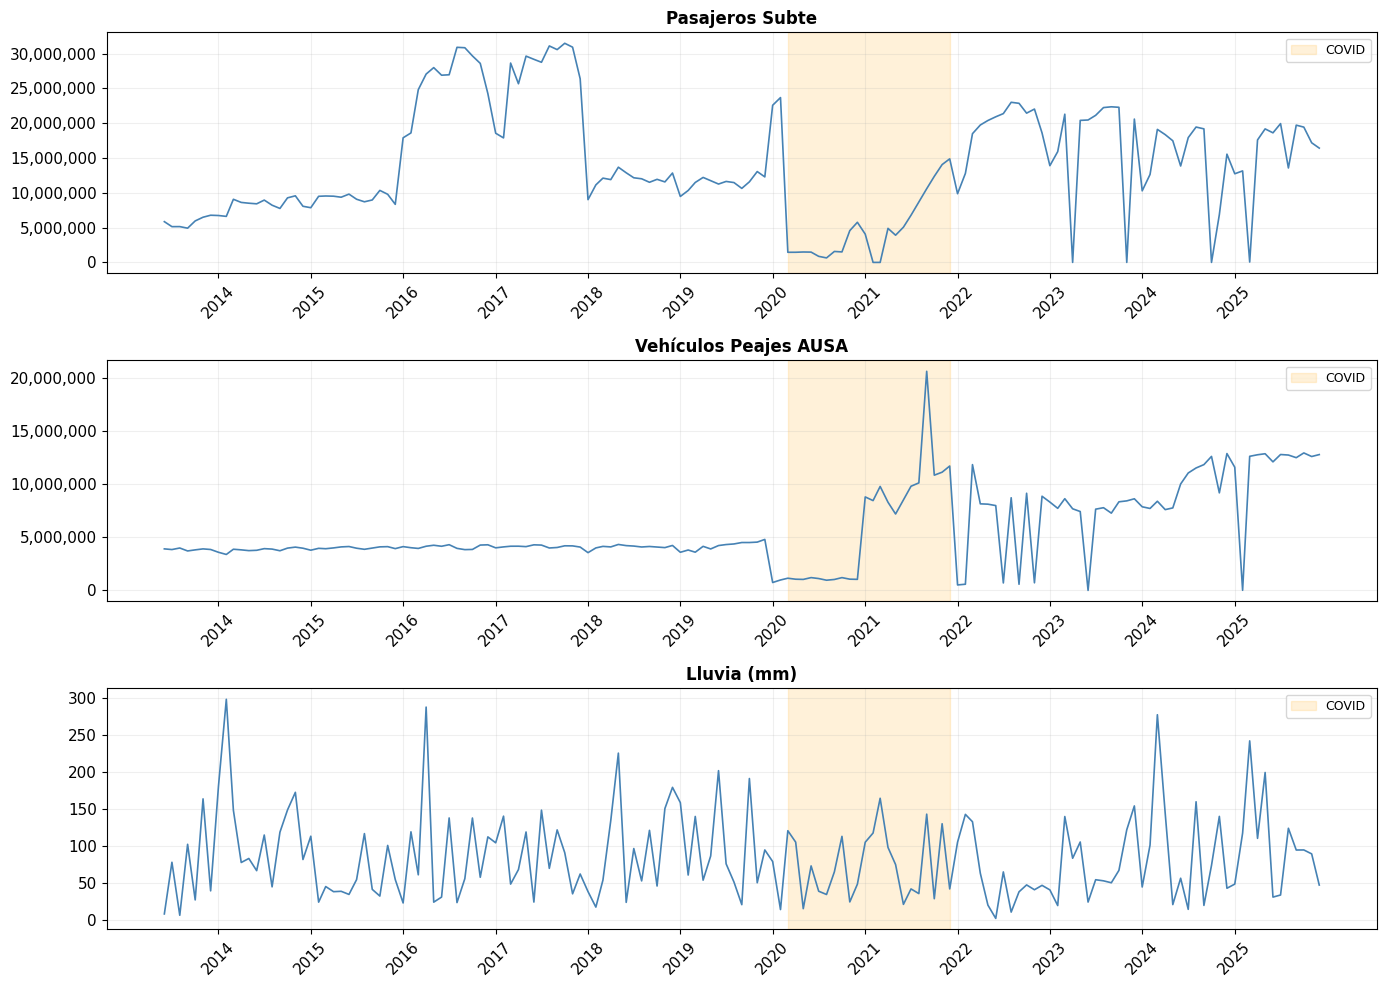

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

series = ['pasajeros_subte', 'vehiculos_peajes', 'lluvia_mm']
títulos = ['Pasajeros Subte', 'Vehículos Peajes AUSA', 'Lluvia (mm)']

covid_start = pd.Timestamp('2020-03-01')
covid_end   = pd.Timestamp('2021-12-01')

for ax, col, titulo in zip(axes, series, títulos):
    ax.plot(df.index, df[col], linewidth=1.2, color='steelblue')
    ax.axvspan(covid_start, covid_end, alpha=0.15, color='orange', label='COVID')
    
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xticks(pd.date_range(df.index.min(), df.index.max(), freq='YS'))
    ax.set_xticklabels([str(t.year) for t in pd.date_range(df.index.min(), df.index.max(), freq='YS')], rotation=45)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

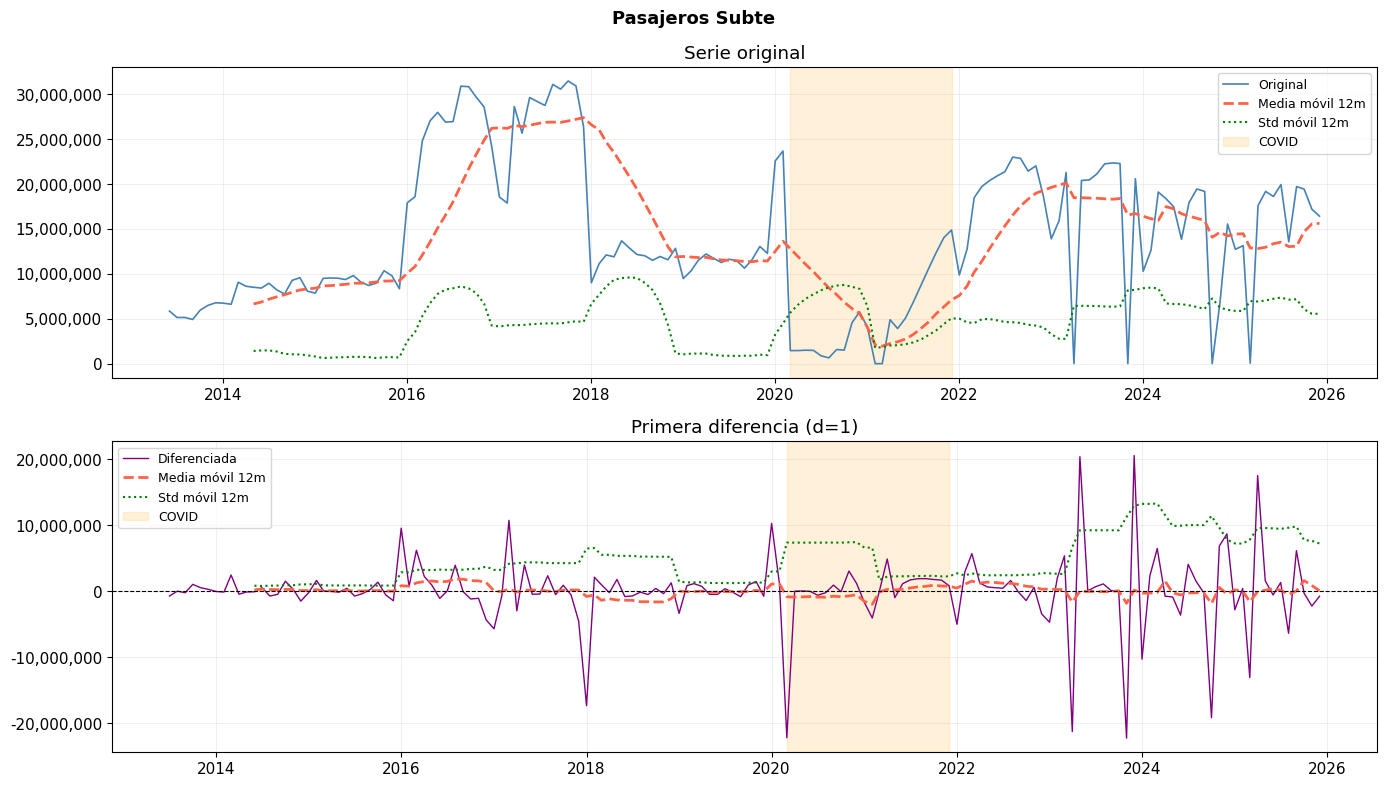

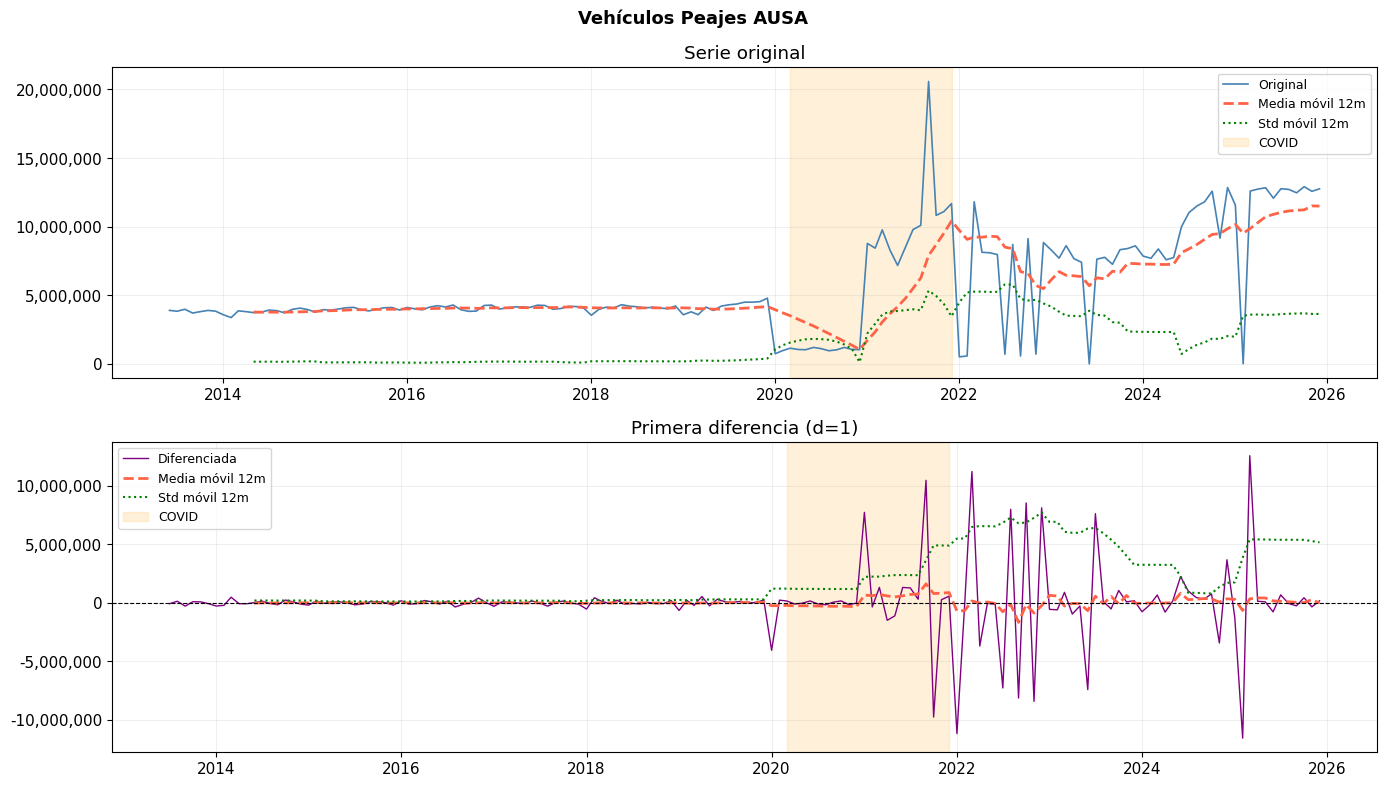

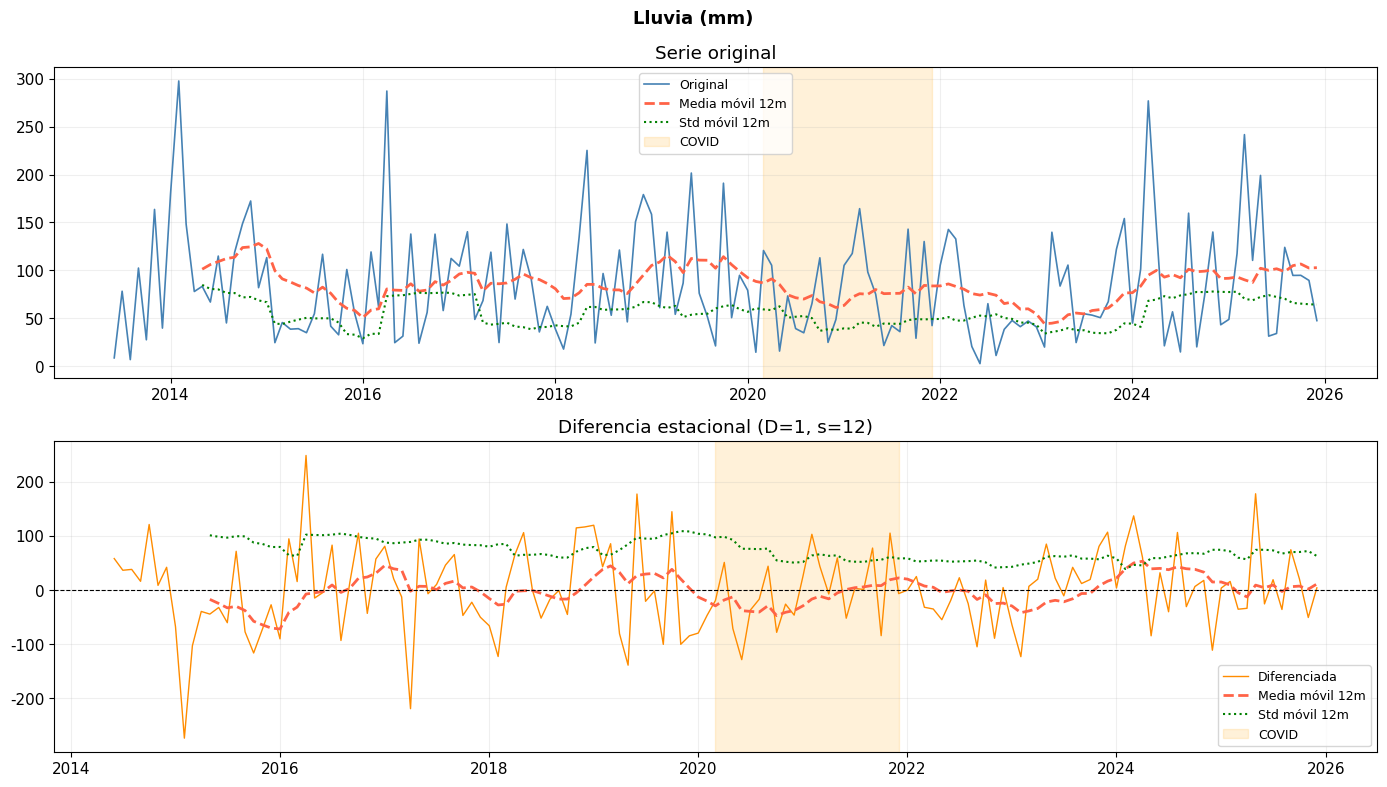

In [20]:
covid_start = pd.Timestamp('2020-03-01')
covid_end   = pd.Timestamp('2021-12-01')

def plot_serie_diff(serie, titulo, diff_serie, diff_titulo, diff_color):
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle(titulo, fontsize=13, fontweight='bold')

    # Serie original + media y std móvil
    rolling_mean = serie.rolling(12).mean()
    rolling_std  = serie.rolling(12).std()
    axes[0].plot(serie, label='Original', linewidth=1.2, color='steelblue')
    axes[0].plot(rolling_mean, label='Media móvil 12m', color='tomato', linewidth=2, linestyle='--')
    axes[0].plot(rolling_std,  label='Std móvil 12m',   color='green',  linewidth=1.5, linestyle=':')
    axes[0].axvspan(covid_start, covid_end, alpha=0.15, color='orange', label='COVID')
    axes[0].set_title('Serie original')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.2)
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    # Serie diferenciada
    rolling_mean_d = diff_serie.rolling(12).mean()
    rolling_std_d  = diff_serie.rolling(12).std()
    axes[1].plot(diff_serie, linewidth=1, color=diff_color, label='Diferenciada')
    axes[1].plot(rolling_mean_d, label='Media móvil 12m', color='tomato', linewidth=2, linestyle='--')
    axes[1].plot(rolling_std_d,  label='Std móvil 12m',   color='green',  linewidth=1.5, linestyle=':')
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].axvspan(covid_start, covid_end, alpha=0.15, color='orange', label='COVID')
    axes[1].set_title(diff_titulo)
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.2)
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    plt.tight_layout()
    plt.show()

# ── Subte: d=1 ──
plot_serie_diff(
    df['pasajeros_subte'], 'Pasajeros Subte',
    df['pasajeros_subte'].diff().dropna(), 'Primera diferencia (d=1)', 'purple'
)

# ── Peajes: d=1 ──
plot_serie_diff(
    df['vehiculos_peajes'], 'Vehículos Peajes AUSA',
    df['vehiculos_peajes'].diff().dropna(), 'Primera diferencia (d=1)', 'purple'
)

# ── Lluvia: D=1, s=12 ──
plot_serie_diff(
    df['lluvia_mm'], 'Lluvia (mm)',
    df['lluvia_mm'].diff(12).dropna(), 'Diferencia estacional (D=1, s=12)', 'darkorange'
)

In [21]:
df_diff = pd.DataFrame(index=df.index)

df_diff['pasajeros_subte_d1']  = df['pasajeros_subte'].diff()
df_diff['vehiculos_peajes_d1'] = df['vehiculos_peajes'].diff()
df_diff['lluvia_mm_D1s12']     = df['lluvia_mm'].diff(12)
df_diff['dummy_covid']         = df['dummy_covid']  # sin transformar

df_diff = df_diff.dropna()

print(df_diff.shape)
display(df_diff.head())

(139, 4)


,pasajeros_subte_d1,vehiculos_peajes_d1,lluvia_mm_D1s12,dummy_covid
fecha,,,,
2014-06-01,-88473.0,31143.0,58.3,0
2014-07-01,535189.0,154586.0,36.7,0
2014-08-01,-734514.0,-41416.0,38.3,0
2014-09-01,-464627.0,-157049.0,16.3,0
2014-10-01,1522172.0,248787.0,121.2,0


## 3. Punto 3
Consigna: Graficar la FAS, FAC y FACP de las mismas en un solo gráfico y analizarlas. ¿Qué puede inferir de
los gráficos?. Justificar con teoría.

## 4.Punto 4
Realizar distintas pruebas de raíces unitarias para determinar si las series elegidas son o no estacionarias